# Proyek Analisis Data: E-commerce Public Dataset
- **Nama:** Evi Novita Gultom
- **Email:** gultomevi22@gmail.com
- **ID Dicoding:** CDCC185D6X1667

## Menentukan Pertanyaan Bisnis

- Daerah mana yang memiliki minat tertinggi dalam berbelanja menggunakan E-commerce?
- Kategori produk mana yang paling sering dibeli?

## Import Semua Packages/Library yang Digunakan

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Wrangling

### Gathering Data

In [26]:
cust = pd.read_csv('https://drive.google.com/uc?id=1QPlTA_jIbHTyGuIyMcKSVRHhEx-Ksa7P')
cust.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [27]:
geographic = pd.read_csv('https://drive.google.com/uc?id=10dhRYlDsi-klDBVBP7xCYm9DjnoqsrE-')
geographic.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [28]:
orders = pd.read_csv('https://drive.google.com/uc?id=1M6vC8mNJ3mopL1snQOzGsErtr7D5-10r')
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [29]:
order_items = pd.read_csv('https://drive.google.com/uc?id=1rKHr_3QnY6yBdFcLjMS3ijM84xLZtc4S')
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [30]:
product = pd.read_csv('https://drive.google.com/uc?id=1RxRvzF3MyD-UblvqR6XR6hcmZafgSlRJ')
product.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- Dengan data di atas, dapat diketahui 5 customer awal berasal dari negara dengan singkatan SP
- Untuk menjawab pertanyaan 1 dibutuhkan letak geografis kota/negara yang memiliki penjualan tertinggi. Selanjutnya, untuk menjawab pertanyaan 2 dibutuhkan nama produk yang banyak terjual pada pemesanan.

### Assessing Data

In [31]:
cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [32]:
geographic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [33]:
orders.info()

# Digunakan untuk mencari jumlah nilai yang hilang :
orders.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [34]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [35]:
product.info()

# Digunakan untuk mencari jumlah nilai yang hilang :
product.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [36]:
payment = pd.read_csv('https://drive.google.com/uc?id=1OnZ_eVHzTyOm5tLz7etIRzlug6t1x6cH')
payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


**Insight:**
- Terdapat missing value pada dataset orders dan product
- Penggunaan tipe data pada orders dan order items, contohnya tanggal pengiriman dan waktu pemesanan tercatat menggunakan tipe data DateTime bukan object.

### Cleaning Data

In [37]:
# Mengisi missing value pada dataset orders

orders.order_approved_at.value_counts()
orders.order_approved_at.fillna(value="2018-02-27 04:31:10", inplace=True)

orders.order_delivered_carrier_date.value_counts()
orders.order_delivered_carrier_date.fillna(value="2018-05-09 15:48:00", inplace=True)

orders.order_delivered_customer_date.value_counts()
orders.order_delivered_customer_date.fillna(value="2018-05-14 20:02:44", inplace=True)
orders.isna().sum()

/tmp/ipykernel_64714/633999454.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  orders.order_approved_at.fillna(value="2018-02-27 04:31:10", inplace=True)
/tmp/ipykernel_64714/633999454.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0


In [38]:
# Mengisi missing value dari dataset products

product.product_category_name.value_counts()
product.product_category_name.fillna(value="cama_mesa_banho", inplace=True)

product.product_name_lenght.value_counts()
product.product_name_lenght.fillna(value=60.0, inplace=True)

product.product_description_lenght.value_counts()
product.product_description_lenght.fillna(value=404.0, inplace=True)

product.product_photos_qty.value_counts()
product.product_photos_qty.fillna(value=1.0, inplace=True)

product.product_weight_g.value_counts()
product.product_weight_g.fillna(value=200.0, inplace=True)

product.product_length_cm.value_counts()
product.product_length_cm.fillna(value=16.0, inplace=True)

product.product_height_cm.value_counts()
product.product_height_cm.fillna(value=10.0, inplace=True)

product.product_width_cm.value_counts()
product.product_width_cm.fillna(value=11.0, inplace=True)

product.isna().sum()

/tmp/ipykernel_64714/767842903.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  product.product_category_name.fillna(value="cama_mesa_banho", inplace=True)
/tmp/ipykernel_64714/767842903.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


In [39]:
# Mengubah tipe data

change_dt = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

for column in change_dt :
  orders[column] = pd.to_datetime(orders[column])

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99441 non-null  datetime64[ns]
 5   order_delivered_carrier_date   99441 non-null  datetime64[ns]
 6   order_delivered_customer_date  99441 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


**Insight:**
- Nilai yang kosong digantikan dengan nilai yang paling banyak digunakan pada jumlah baris data yang ada
- Cukup perlu dikerjakan satu satu untuk memeriksa value counts tiap kolom untuk mengetahui nilai yang paling banyak digunakan
- Dengan mampu mengubah data pada kolom yang kita butuhkan secara langsung, akan meningkatkan kualitas data yang semakin baik dan memudahkan proses analisis maupun penyimpanan

## Exploratory Data Analysis (EDA)

### Explore Daerah yang sering Berbelanja dengan E-Commerce

In [40]:
the_most_order_city = pd.merge(
    left=cust,
    right=orders,
    how='left',
    left_on='customer_id',
    right_on='customer_id'
)

the_most_order_city.groupby(by="customer_city").order_id.nunique().sort_values(ascending=False).reset_index().head(10)

,customer_city,order_id
0,sao paulo,15540
1,rio de janeiro,6882
2,belo horizonte,2773
3,brasilia,2131
4,curitiba,1521
5,campinas,1444
6,porto alegre,1379
7,salvador,1245
8,guarulhos,1189
9,sao bernardo do campo,938


**Insight:**
- Ditampilkan kota-kota yang dapat menjadi target pasar utama perusahaan
- Kota yang teratas merupakan kota yang memiliki arti bahwa menjadi pusat utama hadirnya pelanggan

### Explore Kategori Produk yang Sering Dibeli

In [41]:
top_product = pd.merge(
    left=product,
    right=order_items,
    how='left',
    left_on='product_id',
    right_on='product_id'
)

top_product.groupby(by='product_category_name').order_id.nunique().sort_values(ascending=False).reset_index().head(10)

,product_category_name,order_id
0,cama_mesa_banho,10860
1,beleza_saude,8836
2,esporte_lazer,7720
3,informatica_acessorios,6689
4,moveis_decoracao,6449
5,utilidades_domesticas,5884
6,relogios_presentes,5624
7,telefonia,4199
8,automotivo,3897
9,brinquedos,3886


## Visualization & Explanatory Analysis

### Pertanyaan 1:

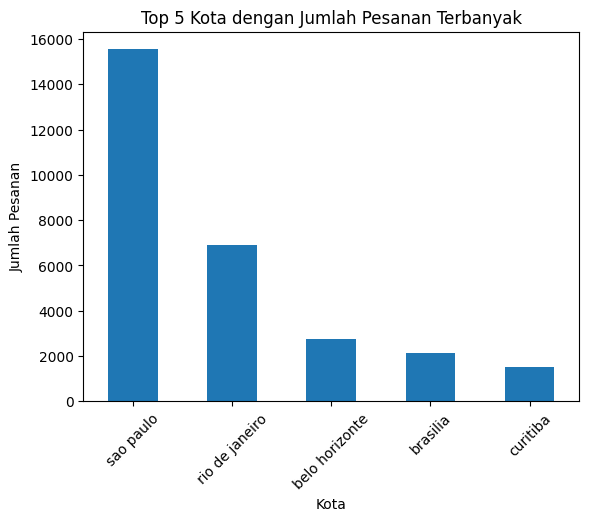

In [42]:
top_city = the_most_order_city.groupby('customer_city')['order_id'] \
    .nunique() \
    .sort_values(ascending=False) \
    .head(5)

plt.figure()
top_city.plot(kind='bar')
plt.title('Top 5 Kota dengan Jumlah Pesanan Terbanyak')
plt.xlabel('Kota')
plt.ylabel('Jumlah Pesanan')
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 2:

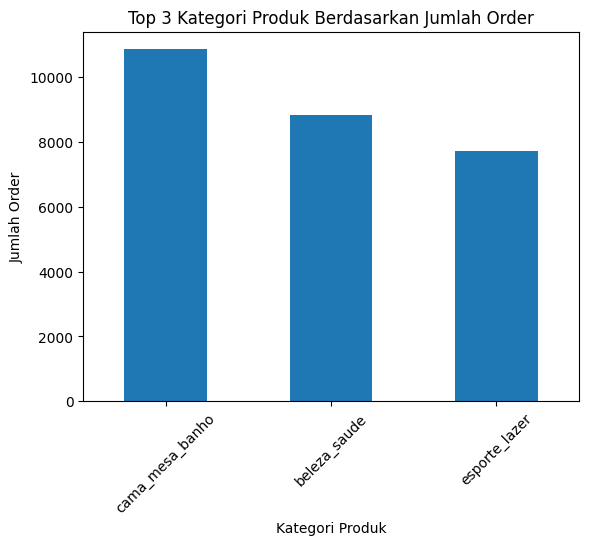

In [43]:
top_category = top_product.groupby('product_category_name')['order_id'] \
    .nunique() \
    .sort_values(ascending=False) \
    .head(3)

plt.figure()
top_category.plot(kind='bar')
plt.title('Top 3 Kategori Produk Berdasarkan Jumlah Order')
plt.xlabel('Kategori Produk')
plt.ylabel('Jumlah Order')
plt.xticks(rotation=45)
plt.show()

**Insight:**
- Pertanyaan 1 : Terdapat perbedaan yang cukup tinggi dari kota yang memiliki jumlah pesanan terbanyak dibandingkan kota lain.
- Pertanyaan 2 : Perbedaan dari top 3 kategori tidak begitu jauh dan terlihat signifikan secara visual

## Analisis Lanjutan (Opsional)

In [44]:
# RFM

rfm = orders.merge(payment, on='order_id')
latest_date = rfm['order_purchase_timestamp'].max()

rfm_analysis = rfm.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (latest_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
})

rfm_analysis.columns = ['Recency', 'Frequency', 'Monetary']
rfm_analysis.head()


,Recency,Frequency,Monetary
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,337,1,114.74
000161a058600d5901f007fab4c27140,458,1,67.41
0001fd6190edaaf884bcaf3d49edf079,596,1,195.42
0002414f95344307404f0ace7a26f1d5,427,1,179.35
000379cdec625522490c315e70c7a9fb,198,1,107.01


In [45]:
#Geospatial

import folium

peta = folium.Map(location=[-14, -51], zoom_start=5)

for _, row in geographic.sample(1000).iterrows():
    folium.CircleMarker(
        location=[row['geolocation_lat'], row['geolocation_lng']],
        radius=2
    ).add_to(peta)

peta

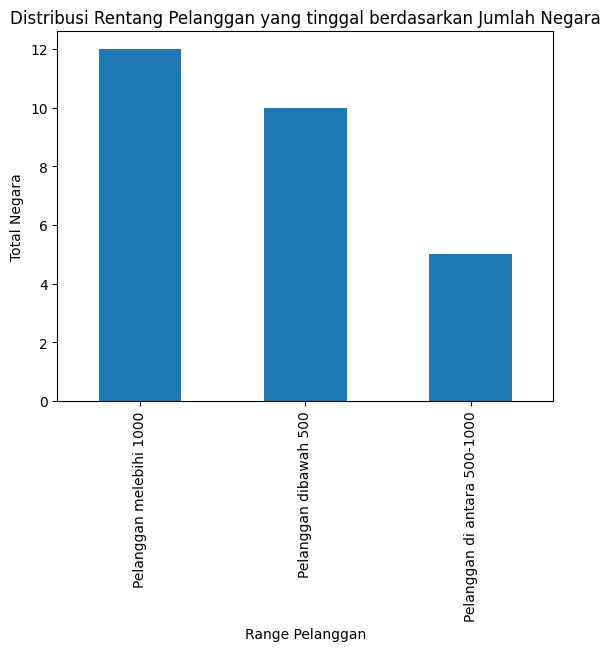

In [46]:
# Clustering

# Manual Groupping untuk berdasarkan Negara - 1
city_customer = cust.groupby('customer_state')['customer_id'] \
    .nunique() \
    .reset_index()

def jumlah(x) :
  if x > 1000 :
    return 'Pelanggan melebihi 1000'
  elif x >= 500 :
    return 'Pelanggan di antara 500-1000'
  else :
    return 'Pelanggan dibawah 500'

city_customer['jumlah_pelanggan'] = city_customer['customer_id'].apply(jumlah)
city_customer['jumlah_pelanggan'].value_counts().plot(kind='bar')

plt.title('Distribusi Rentang Pelanggan yang tinggal berdasarkan Jumlah Negara')
plt.xlabel('Range Pelanggan')
plt.ylabel('Total Negara')
plt.show()

In [47]:
# Clustering - 2

rfm_analysis['R_bin'] = pd.qcut(rfm_analysis['Recency'], 3, labels=['Baru', 'Sedang', 'Lama'])
rfm_analysis['M_bin'] = pd.qcut(rfm_analysis['Monetary'], 3, labels=['Rendah', 'Sedang', 'Tinggi'])

rfm_analysis[['R_bin','M_bin']].head()

,R_bin,M_bin
customer_id,,
00012a2ce6f8dcda20d059ce98491703,Sedang,Sedang
000161a058600d5901f007fab4c27140,Lama,Rendah
0001fd6190edaaf884bcaf3d49edf079,Lama,Tinggi
0002414f95344307404f0ace7a26f1d5,Lama,Tinggi
000379cdec625522490c315e70c7a9fb,Baru,Sedang


In [48]:
cust.to_csv('cust.csv', index=False)
geographic.to_csv('geographic.csv', index=False)
orders.to_csv('orders.csv', index=False)
order_items.to_csv('order_items.csv', index=False)
product.to_csv('product.csv', index=False)
payment.to_csv('payment.csv', index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Conclusion

- Kesimpulan dari pertanyaan 1 ialah Kota yang memiliki jumlah order terbanyak adalah Kota Sao Paulo. Dengan ini, perusahaan dapat memutuskan banyak hal dari jumlah pemasokan barang, target pasar utama dan lain-lain.
- Kesimpulan dari pertanyaan 2 ialah Kategori Produk dengan nilai penjualan tertinggi ialah Cama Mesa Banho. Perusahaan juga dapat menjadikan data ini menjadi tolak ukur untuk developing produk-produk barunya.